# METOP2





In [1]:
import pandas as pd
import os
import numpy as np
import math
import pdb
import datetime
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split

In [2]:
wd = os.getcwd() #working directory
fname_txt = 'matfile_METOP2.mat'
fpath_txt = os.path.join(wd, fname_txt)
mat_data = loadmat(fpath_txt)

print(mat_data.keys())

variable_names = ['ConjDatenum', 'L', 'MLT', 'MLAT', 'MLAT_rbsp',
                  'NorthSouth', 'MLON', 'Lat_poes', 'Lon_poes',
                  'Poes90Flux','Poes90PA','Poes0Flux','Poes0PA','C', 'N','AE',
                  'AEsub0','AEsub1','AEsub2','AEsub3',
                  'AEsub4','AEsub5','AEsub6','AEsub7','AEsub8','AEsub9','AEsub10','AEsub11',
                  'AEsub12','AEsub13','AEsub14','AEsub15','AEsub16','AEsub17','AEsub18',
                  'AEsub19','AEsub20','AEsub21','AEsub22','AEsub23','AEsub24','AEsub25',
                  'AEsub26','AEsub27','AEsub28','AEsub29','AEsub30','AEsub31','AEsub32',
                  'AEsub33','AEsub34','AEsub35']


df_list= []
for var in variable_names:
    if var in mat_data:  # Check if the variable exists in the .mat file
        data = mat_data[var]
        df_list.append(pd.DataFrame(data, columns=[var]))  # Add variable data as a new column
        print(f"Converted {var} to DataFrame")
    else:
        print(f"{var} not found in the .mat file")

data_base = pd.concat(df_list, axis=1)
data_base["log_flux0"] = np.log10(data_base["Poes0Flux"])
data_base["log_flux90"] = np.log10(data_base["Poes90Flux"])
data_base.replace([np.inf, -np.inf], np.nan, inplace=True)
#drop every row where a NaN, inf exists: see https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html
data_base.dropna(axis=0, inplace=True)

data_base


dict_keys(['__header__', '__version__', '__globals__', 'AE', 'AEsub0', 'AEsub1', 'AEsub10', 'AEsub11', 'AEsub12', 'AEsub13', 'AEsub14', 'AEsub15', 'AEsub16', 'AEsub17', 'AEsub18', 'AEsub19', 'AEsub2', 'AEsub20', 'AEsub21', 'AEsub22', 'AEsub23', 'AEsub24', 'AEsub25', 'AEsub26', 'AEsub27', 'AEsub28', 'AEsub29', 'AEsub3', 'AEsub30', 'AEsub31', 'AEsub32', 'AEsub33', 'AEsub34', 'AEsub35', 'AEsub4', 'AEsub5', 'AEsub6', 'AEsub7', 'AEsub8', 'AEsub9', 'C', 'ConjDatenum', 'L', 'Lat_poes', 'Lon_poes', 'MLAT', 'MLAT_rbsp', 'MLON', 'MLT', 'N', 'NorthSouth', 'Poes0Flux', 'Poes0PA', 'Poes90Flux', 'Poes90PA'])
Converted ConjDatenum to DataFrame
Converted L to DataFrame
Converted MLT to DataFrame
Converted MLAT to DataFrame
Converted MLAT_rbsp to DataFrame
Converted NorthSouth to DataFrame
Converted MLON to DataFrame
Converted Lat_poes to DataFrame
Converted Lon_poes to DataFrame
Converted Poes90Flux to DataFrame
Converted Poes90PA to DataFrame
Converted Poes0Flux to DataFrame
Converted Poes0PA to Data

,ConjDatenum,L,MLT,MLAT,MLAT_rbsp,NorthSouth,MLON,Lat_poes,Lon_poes,Poes90Flux,...,AEsub28,AEsub29,AEsub30,AEsub31,AEsub32,AEsub33,AEsub34,AEsub35,log_flux0,log_flux90
0,735447.149318,6.278001,20.161642,63.308639,15.031034,0,318.316251,55.596001,255.738007,47701.613281,...,106,111,113,96,83,82,88,92,2.383700,4.678533
1,735447.149364,6.392297,20.154249,63.518020,15.029175,0,318.055557,55.824001,255.610001,52862.902344,...,106,111,113,96,83,82,88,92,2.207608,4.723151
2,735447.433507,5.554937,19.434353,59.767115,-0.114826,0,205.891388,68.296997,143.776001,58024.191406,...,125,130,123,142,156,150,132,110,1.906578,4.763609
3,735447.433530,5.602855,19.427072,59.863125,-0.115327,0,205.747902,68.404999,143.636993,65766.125000,...,125,130,123,142,156,150,132,110,2.508638,4.818002
4,735447.433553,5.652709,19.419813,59.958135,-0.115827,0,205.604181,68.512001,143.496994,72862.906250,...,125,130,123,142,156,150,132,110,1.906578,4.862506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23508,737618.580909,2.830855,8.288082,-53.743014,4.879251,1,346.486435,-62.980000,269.703003,22540.322266,...,313,315,303,296,319,355,280,247,1.906578,4.352960
23509,737618.580932,2.844434,8.287437,-53.858613,4.876167,1,346.430227,-63.091999,269.609009,23830.644531,...,313,315,303,296,319,355,280,247,2.207608,4.377136
23510,737618.580955,2.858435,8.286820,-53.973187,4.873079,1,346.374878,-63.202999,269.515991,22540.322266,...,313,315,303,296,319,355,280,247,1.906578,4.352960
23511,737618.581001,2.887344,8.285496,-54.202518,4.866909,1,346.261900,-63.424999,269.325989,22540.322266,...,313,315,303,296,319,355,280,247,2.207608,4.352960


In [3]:
#Partition the training data
part1 = data_base.iloc[579:14940,:]
part2 = data_base.iloc[18367:, :]
data_training = pd.concat([part1, part2], axis=0)

data_testing = data_base.iloc[14940:18367,:]

print(data_training.shape)
print(data_testing.shape)

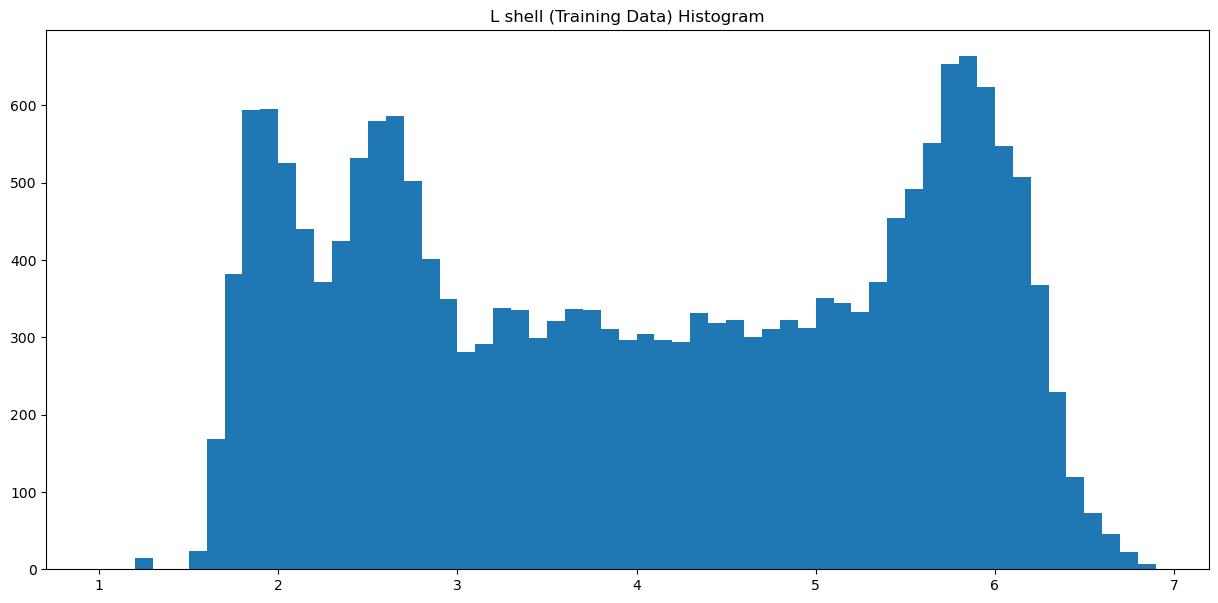

In [4]:
# Creating plot to show the spread in L shell
fig = plt.figure(figsize =(15, 7))
plt.hist(data_training["L"].values, bins=np.arange(1,7,0.1))
plt.title("L shell (Training Data) Histogram")
plt.show()

#**Establishing Train and Test data**
Create arrays: X_data(inputs), y_data(outputs)

In [5]:
X_data = data_training[["log_flux90", "log_flux0","L","MLT", "MLAT", "MLON","Lat_poes", "Lon_poes",
                         "AEsub0","AEsub1","AEsub2","AEsub3",
                         "AEsub4","AEsub5","AEsub6","AEsub7","AEsub8","AEsub9","AEsub10","AEsub11",
                         "AEsub12","AEsub13","AEsub14","AEsub15","AEsub16","AEsub17","AEsub18",
                         "AEsub19","AEsub20","AEsub21","AEsub22","AEsub23","AEsub24","AEsub25",
                         "AEsub26","AEsub27","AEsub28","AEsub29","AEsub30","AEsub31","AEsub32",
                         "AEsub33","AEsub34","AEsub35"]].values

y_data=data_training[["C","N"]].values

test_size = 0.3

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=test_size, random_state=0)
# use the random_state argument to make sure results are deterministic

#**Training MLPRegressor**

In [6]:
# @title Build and train a the MLPR Model

scalerX = StandardScaler().fit(X_train)
X_train = scalerX.transform(X_train)
X_test = scalerX.transform(X_test)

regr_ann = MLPRegressor(random_state = 0, solver='adam', activation='relu',max_iter=1000,learning_rate_init= 0.001,
                        learning_rate = 'adaptive',hidden_layer_sizes = (100,100),verbose=False ) # random_state argument to make results deterministic


regr_ann.fit(X_train,y_train)
y_pred_ann = regr_ann.predict(X_test)

In [8]:
print('Held out, R2: ' ,metrics.r2_score(y_test, y_pred_ann))
print('In Sample, R2: ' ,metrics.r2_score(y_train, regr_ann.predict(X_train)))

Held out, R2:  0.9721793669158851
In Sample, R2:  0.98198099877322


# **Testing**

In [9]:
# @title Loading Out of Sample POES data (2sec cadence), NOT conjunction based
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
fname_txt = 'MetOp2_May2017Feb2018.mat'
fpath_txt = os.path.join(wd, fname_txt)
val_data = loadmat(fpath_txt)

print(val_data.keys())

variable_names = ['L_runninglist', 'MLT_runninglist', 'MLAT_runninglist', 'MLON_runninglist',
                  'Lat_runninglist', 'Lon_runninglist', 'NorthSouth_runninglist',
                  'Flux90_runninglist','Flux0_runninglist',
                  "AEsub0","AEsub1","AEsub2","AEsub3",
                  "AEsub4","AEsub5","AEsub6","AEsub7","AEsub8","AEsub9","AEsub10","AEsub11",
                  "AEsub12","AEsub13","AEsub14","AEsub15","AEsub16","AEsub17","AEsub18",
                  "AEsub19","AEsub20","AEsub21","AEsub22","AEsub23","AEsub24","AEsub25",
                  "AEsub26","AEsub27","AEsub28","AEsub29","AEsub30","AEsub31","AEsub32",
                  "AEsub33","AEsub34","AEsub35", "Datenum_runninglist"]

df_list= []
for var in variable_names:
    if var in val_data:  # Check if the variable exists in the .mat file
        vardata = val_data[var]
        if vardata.shape[1] == 4:  # If vardata has 4 columns
          df_list.append(pd.DataFrame(vardata, columns=[f"{var}_1", f"{var}_2", f"{var}_3", f"{var}_4"]))
          print(f"Converted 4 {var} to DataFrame")
        else:
          df_list.append(pd.DataFrame(vardata, columns=[var]))  # Add variable data as a new column
          print(f"Converted {var} to DataFrame")
    else:
        print(f"{var} not found in the .mat file")

dataval_base = pd.concat(df_list, axis=1)
dataval_base["log_flux0"] = np.log10(dataval_base["Flux0_runninglist_1"])
dataval_base["log_flux90"] = np.log10(dataval_base["Flux90_runninglist_1"])
dataval_base["L"] = (dataval_base["L_runninglist"])
dataval_base["MLT"] = (dataval_base["MLT_runninglist"])
dataval_base["MLAT"] = (dataval_base["MLAT_runninglist"])
dataval_base["MLON"] = (dataval_base["MLON_runninglist"])
dataval_base["Lat_poes"] = (dataval_base["Lat_runninglist"])
dataval_base["Lon_poes"] = (dataval_base["Lon_runninglist"])

dataval_base.replace([np.inf, -np.inf], np.nan, inplace=True)
dataval_base.dropna(axis=0, inplace=True)

dict_keys(['__header__', '__version__', '__globals__', 'AE_runninglist', 'AEstar3hravg_runninglist', 'AEstar3hrmax_runninglist', 'AEstar3hrmin_runninglist', 'AEsub0', 'AEsub1', 'AEsub10', 'AEsub11', 'AEsub12', 'AEsub13', 'AEsub14', 'AEsub15', 'AEsub16', 'AEsub17', 'AEsub18', 'AEsub19', 'AEsub2', 'AEsub20', 'AEsub21', 'AEsub22', 'AEsub23', 'AEsub24', 'AEsub25', 'AEsub26', 'AEsub27', 'AEsub28', 'AEsub29', 'AEsub3', 'AEsub30', 'AEsub31', 'AEsub32', 'AEsub33', 'AEsub34', 'AEsub35', 'AEsub4', 'AEsub5', 'AEsub6', 'AEsub7', 'AEsub8', 'AEsub9', 'BoverBeq_poes_runninglist', 'Datenum_runninglist', 'Flux0_runninglist', 'Flux90_runninglist', 'L_runninglist', 'Lat_runninglist', 'Lon_runninglist', 'MLAT_runninglist', 'MLON_runninglist', 'MLT_runninglist', 'NorthSouth_runninglist', 'PA0_runninglist', 'PA90_runninglist'])
Converted L_runninglist to DataFrame
Converted MLT_runninglist to DataFrame
Converted MLAT_runninglist to DataFrame
Converted MLON_runninglist to DataFrame
Converted Lat_runninglist 

In [11]:
## NOT on conjunction basis
X_data_testing = dataval_base[["log_flux90", "log_flux0","L","MLT","MLAT", "MLON","Lat_poes", "Lon_poes",
                               "AEsub0","AEsub1","AEsub2","AEsub3",
                               "AEsub4","AEsub5","AEsub6","AEsub7","AEsub8","AEsub9","AEsub10","AEsub11",
                               "AEsub12","AEsub13","AEsub14","AEsub15","AEsub16","AEsub17","AEsub18",
                               "AEsub19","AEsub20","AEsub21","AEsub22","AEsub23","AEsub24","AEsub25",
                               "AEsub26","AEsub27","AEsub28","AEsub29","AEsub30","AEsub31","AEsub32",
                               "AEsub33","AEsub34","AEsub35"]].values

y_pred_test = regr_ann.predict(scalerX.transform(X_data_testing))
data_to_save = {'ALL_C': y_pred_test[:,0], 'ALL_N': y_pred_test[:,1]}
filename = f"outputs_test_METOP2.mat"
#savemat(filename, data_to_save)

In [12]:
## IS ON on conjunction basis
X_data_validation = data_testing[["log_flux90", "log_flux0","L","MLT", "MLAT", "MLON","Lat_poes", "Lon_poes",
                         "AEsub0","AEsub1","AEsub2","AEsub3",
                         "AEsub4","AEsub5","AEsub6","AEsub7","AEsub8","AEsub9","AEsub10","AEsub11",
                         "AEsub12","AEsub13","AEsub14","AEsub15","AEsub16","AEsub17","AEsub18",
                         "AEsub19","AEsub20","AEsub21","AEsub22","AEsub23","AEsub24","AEsub25",
                         "AEsub26","AEsub27","AEsub28","AEsub29","AEsub30","AEsub31","AEsub32",
                         "AEsub33","AEsub34","AEsub35"]].values
y_pred_val = regr_ann.predict(scalerX.transform(X_data_validation))
data_to_save = {'C_conj': y_pred_val[:,0], 'N_conj': y_pred_val[:,1]}
filename = f"outputs_val_METOP2.mat"
#savemat(filename, data_to_save)